# Week 3 Session 6: Tuning a CNN + Meet a Transformer

This session has two halves:

1. **Tune the CNN** from Session 5 -- look inside it, then sweep through hyperparameters and see which ones actually move test accuracy.
2. **Meet a different brain** -- the Vision Transformer (ViT). We use a pre-trained ViT from Hugging Face and run it on the same images, head to head with the CNN.

## Activities in this Session

| # | Activity | Topic | Style |
|---|----------|-------|-------|
| 1 | Inside the CNN | Filter & feature-map visualisation | Worked + 1 TODO |
| 2 | Hyperparameter experiments | Kernel size, filter count, pooling, dropout, depth, custom config | Worked + 3 TODOs |
| 3 | A different brain: ViT | Hugging Face image-classification pipeline, CNN vs ViT | Worked + 1 TODO |

> **Heads up:** the first time we load the ViT pipeline Hugging Face will download ~350 MB. Run the install/import cell early.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

# Require GPU training for this notebook run
REQUIRE_GPU = True
gpus = tf.config.list_physical_devices('GPU')

print('TensorFlow version:', tf.__version__)
print('GPU devices:', gpus)

# Use GPU if available, otherwise use CPU
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    TRAIN_DEVICE = '/GPU:0'
    print('Using GPU:', gpus)
else:
    TRAIN_DEVICE = '/CPU:0'
    print('No GPU found. Using CPU.')


TensorFlow version: 2.18.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


X_train: (10000, 32, 32, 3)   X_test: (2000, 32, 32, 3)


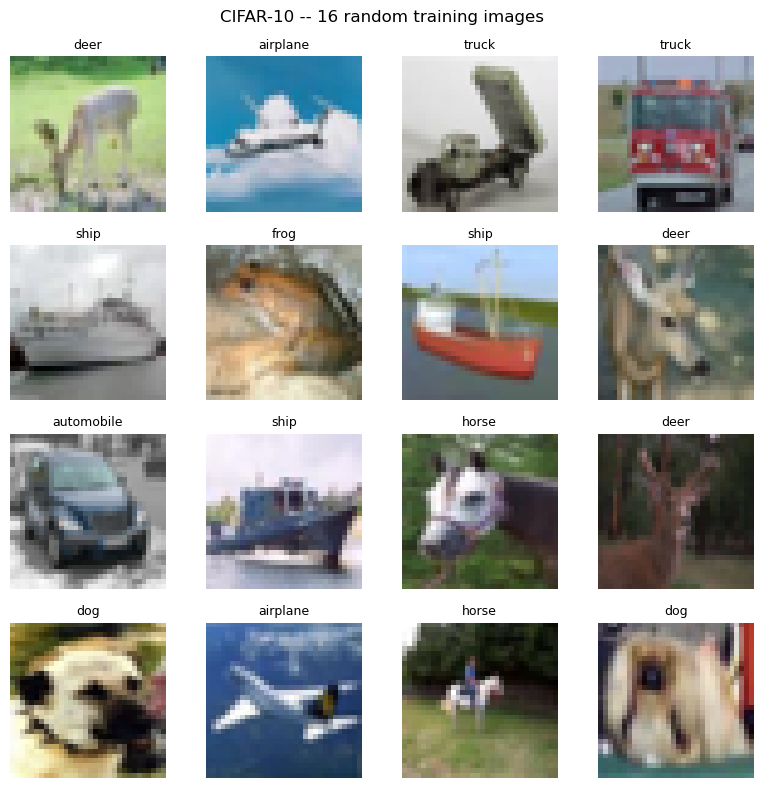

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

# Option: use full dataset or a smaller subset
USE_SMALL_SUBSET = True

TRAIN_SUBSET_SIZE = 10000
TEST_SUBSET_SIZE = 2000

# Load the full CIFAR-10 dataset
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()

rng = np.random.default_rng(42)

if USE_SMALL_SUBSET:
    train_idx = rng.permutation(len(X_train_full))[:TRAIN_SUBSET_SIZE]
    test_idx = rng.permutation(len(X_test_full))[:TEST_SUBSET_SIZE]

    X_train = X_train_full[train_idx].astype('float32') / 255.0
    X_test = X_test_full[test_idx].astype('float32') / 255.0

    y_train = y_train_full[train_idx].flatten()
    y_test = y_test_full[test_idx].flatten()
else:
    X_train = X_train_full.astype('float32') / 255.0
    X_test = X_test_full.astype('float32') / 255.0

    y_train = y_train_full.flatten()
    y_test = y_test_full.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')

# Show 16 random images in a 4x4 grid with their class labels
sample_indices = rng.choice(len(X_train), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, idx in zip(axes.flat, sample_indices):
    ax.imshow(X_train[idx])
    ax.set_title(class_names[int(y_train[idx])], fontsize=9)
    ax.axis('off')

plt.suptitle('CIFAR-10 -- 16 random training images')
plt.tight_layout()
plt.show()

---
# Activity 1 -- Dense NN Baseline on CIFAR-10

In [3]:
# define a simple mode
model_dense = models.Sequential()
model_dense.add(layers.Input(shape=(32, 32, 3)))
model_dense.add(layers.Flatten())
model_dense.add(layers.Dense(128, use_bias=False))
model_dense.add(layers.BatchNormalization())
model_dense.add(layers.Activation('relu'))
model_dense.add(layers.Dropout(0.5))

model_dense.add(layers.Dense(10, activation='softmax'))

model_dense.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

model_dense.summary()

# fit the model to the training data
history_dense = model_dense.fit(X_train, y_train,
                                epochs=10,
                                batch_size=64,
                                validation_data=(X_test, y_test))

# evaluate the model on the test set
test_loss_dense, test_acc_dense = model_dense.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy (Dense): {test_acc_dense:.4f}')

2026-05-17 11:50:52.238937: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-05-17 11:50:52.238968: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-05-17 11:50:52.238977: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1778975452.238990   87795 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1778975452.239008   87795 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,018 (1.51 MB)

 Trainable params: 394,762 (1.51 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/10


2026-05-17 11:50:53.544070: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.3398 - loss: 1.8990 - val_accuracy: 0.3721 - val_loss: 1.7520
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4030 - loss: 1.6988 - val_accuracy: 0.4164 - val_loss: 1.6566
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4197 - loss: 1.6461 - val_accuracy: 0.4065 - val_loss: 1.6581
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4329 - loss: 1.6154 - val_accuracy: 0.4150 - val_loss: 1.6480
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4434 - loss: 1.5881 - val_accuracy: 0.3783 - val_loss: 1.7364
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4513 - loss: 1.5649 - val_accuracy: 0.3954 - val_loss: 1.6736
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4555 - loss: 1.5476 - val_accuracy: 0.4351 - val_loss: 1.5987
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4673 - loss: 1.5230 - val_accuracy: 0.4

---
# Activity 2 -- Inside the CNN

> ### Activity Card
> **Goal:** Visualise what the CNN actually learned -- the filters in the first conv layer and the feature maps they produce on a real image.
> **Why this matters:** This is the moment a CNN stops being a black box. Filters look like edge / colour / texture detectors. Feature maps show where in the image those patterns live.

In [4]:
# define a simple CNN model
with tf.device(TRAIN_DEVICE):
    model_cnn = models.Sequential()
    model_cnn.add(layers.Input(shape=(32, 32, 3)))

    model_cnn.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model_cnn.add(layers.MaxPooling2D((2, 2)))
    model_cnn.add(layers.Dropout(0.25))

    model_cnn.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model_cnn.add(layers.MaxPooling2D((2, 2)))
    model_cnn.add(layers.Dropout(0.25))

    model_cnn.add(layers.Flatten())
    model_cnn.add(layers.Dense(128, activation='relu'))
    model_cnn.add(layers.Dropout(0.5))

    model_cnn.add(layers.Dense(10, activation='softmax'))

    model_cnn.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

    model_cnn.summary()

    # fit the model to the training data
    history_cnn = model_cnn.fit(X_train, y_train,
                                epochs=10,
                                batch_size=64,
                                validation_data=(X_test, y_test))

    # evaluate the model on the test set
    test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test, y_test, verbose=2)

baseline_acc = test_acc_cnn
print(f'Test accuracy (Baseline CNN): {test_acc_cnn:.4f}')

2026-05-17 14:49:02.666505: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-05-17 14:49:02.666565: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-05-17 14:49:02.666572: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1778986142.667147   15962 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1778986142.667631   15962 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


2026-05-17 14:49:03.342263: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.1930 - loss: 2.2105 - val_accuracy: 0.3120 - val_loss: 1.8958
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2946 - loss: 1.9379 - val_accuracy: 0.3995 - val_loss: 1.6696
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3435 - loss: 1.7943 - val_accuracy: 0.4625 - val_loss: 1.5432
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3858 - loss: 1.6882 - val_accuracy: 0.4835 - val_loss: 1.4406
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4251 - loss: 1.6035 - val_accuracy: 0.5230 - val_loss: 1.3831
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4449 - loss: 1.5307 - val_accuracy: 0.5280 - val_loss: 1.3384
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4722 - loss: 1.4822 - val_accuracy: 0.5430 - val_loss: 1.2825
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4858 - loss: 1.4225 - val_accuracy: 0.557

---
# Activity 3 -- Simple Vision Transformer on CIFAR-10

This ViT is trained from scratch on the same CIFAR-10 data as the Dense NN and CNN.

The image is split into small patches, each patch becomes a token, and self-attention learns how the patches relate to each other.

### What is a Transformer (in one paragraph)?
A transformer chops the image into small **patches** (here 16x16), turns each patch into a vector, and then asks a single question over and over: *"how much should each patch pay attention to every other patch?"* That mechanism is called **self-attention**, and it replaces convolution entirely.

Important: ViT was pre-trained on ImageNet, so its 1,000 class names are different from CIFAR-10's 10. We will see "tabby cat" instead of "cat", "sports car" instead of "automobile". That is normal -- the goal is to compare top-1 predictions side by side, not class IDs.

In [5]:
# Simple ViT trained on CIFAR-10
class PositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.num_patches = num_patches
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=embed_dim
        )

    def call(self, x):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return x + self.position_embedding(positions)


def build_simple_vit(input_shape=(32, 32, 3), num_classes=10):
    patch_size = 4
    embed_dim = 64
    num_heads = 4
    transformer_blocks = 2
    mlp_dim = 128

    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)

    inputs = layers.Input(shape=input_shape)

    # Convert image patches into tokens
    x = layers.Conv2D(
        filters=embed_dim,
        kernel_size=patch_size,
        strides=patch_size,
        padding='valid'
    )(inputs)

    x = layers.Reshape((num_patches, embed_dim))(x)
    x = PositionEmbedding(num_patches, embed_dim)(x)

    # Transformer encoder blocks
    for _ in range(transformer_blocks):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=0.1
        )(x1, x1)

        x = layers.Add()([x, attention])

        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        x1 = layers.Dense(mlp_dim, activation='gelu')(x1)
        x1 = layers.Dropout(0.1)(x1)
        x1 = layers.Dense(embed_dim)(x1)

        x = layers.Add()([x, x1])

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='simple_vit_cifar10')


with tf.device(TRAIN_DEVICE):
    model_vit = build_simple_vit()

    model_vit.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model_vit.summary()

    history_vit = model_vit.fit(
        X_train, y_train,
        epochs=10,
        batch_size=64,
        validation_data=(X_test, y_test)
    )

    test_loss_vit, test_acc_vit = model_vit.evaluate(X_test, y_test, verbose=2)

print(f'Test accuracy (Simple ViT): {test_acc_vit:.4f}')

Model: "simple_vit_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 64)  │      3,136 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 64)    │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, 64, 64)    │      4,096 │ reshape[0][0]     │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ position_embeddi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ position_embeddi… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64, 128)   │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ add_1[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64, 128)   │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 79,114 (309.04 KB)

 Trainable params: 79,114 (309.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 83ms/step - accuracy: 0.2020 - loss: 2.4327 - val_accuracy: 0.2942 - val_loss: 1.8097
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.3023 - loss: 1.9761 - val_accuracy: 0.4093 - val_loss: 1.5954
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - accuracy: 0.3671 - loss: 1.7599 - val_accuracy: 0.4314 - val_loss: 1.5767
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.4174 - loss: 1.6235 - val_accuracy: 0.4735 - val_loss: 1.4556
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.4482 - loss: 1.5382 - val_accuracy: 0.4960 - val_loss: 1.3962
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 107ms/step - accuracy: 0.4687 - loss: 1.4898 - val_accuracy: 0.4953 - val_loss: 1.4006
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.4840 - loss: 1.4442 - val_accuracy: 0.5109 - val_loss: 1.3557
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.4972 - loss: 1.4117 

---
# Activity 4 -- Pre-trained ViT on CIFAR-10 Images

Now we use a pre-trained Vision Transformer from Hugging Face.

Important: this model was trained on ImageNet, not CIFAR-10. So it predicts labels like `tabby cat`, `sports car`, or `airliner` instead of the exact CIFAR-10 labels. We use it for comparison on the same test images, not for a direct CIFAR-10 accuracy score.

In [6]:
# Pre-trained ViT from Hugging Face
from transformers import pipeline
from PIL import Image

vit_pretrained = pipeline(
    task='image-classification',
    model='google/vit-base-patch16-224',
    framework='pt',
    device=0,
    top_k=3
)

print('Pre-trained ViT ready.')

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use mps:0


Pre-trained ViT ready.


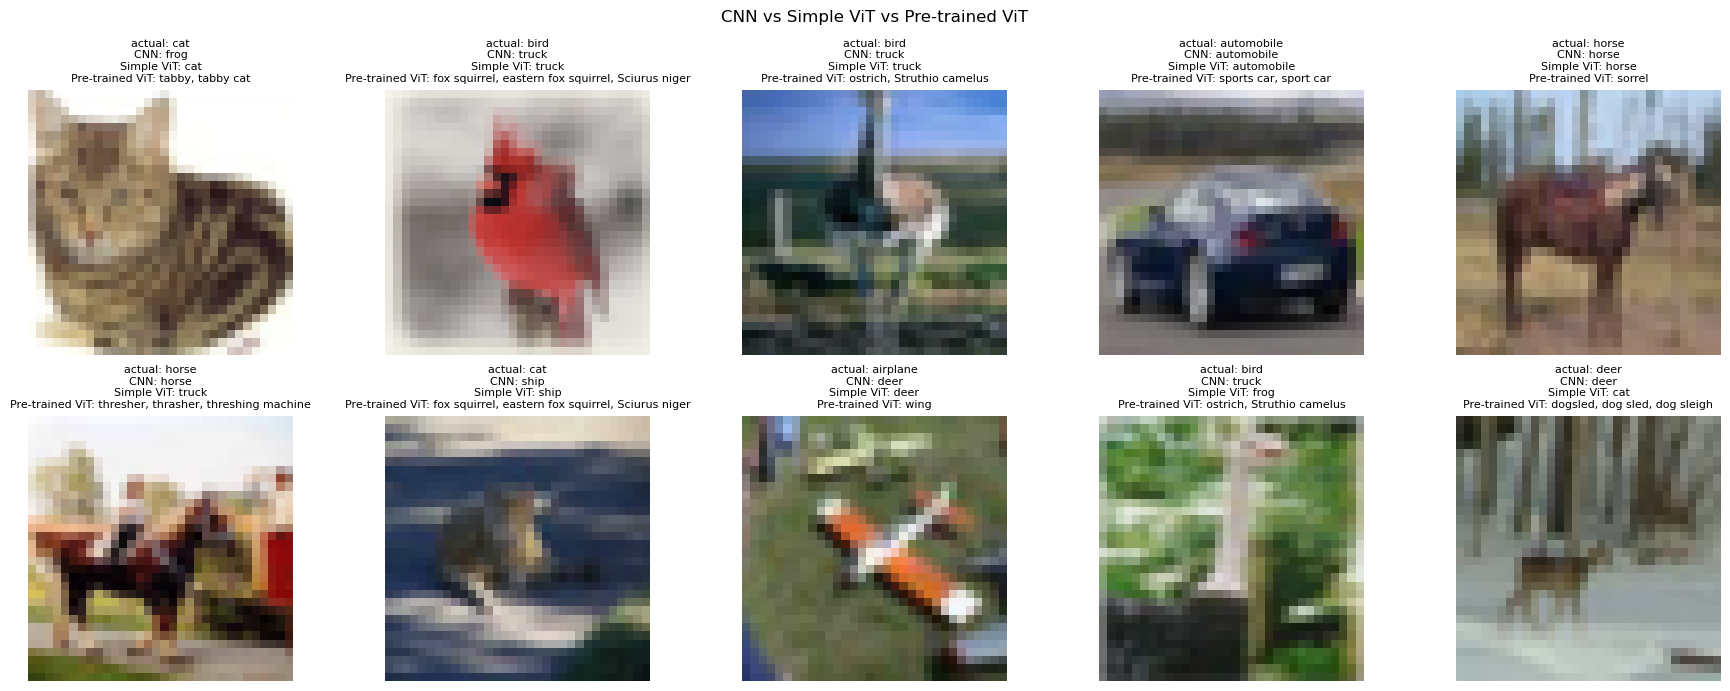

In [7]:
# Test the pre-trained ViT on random CIFAR-10 images
num_examples = 10

rng = np.random.default_rng()
sample_indices = rng.choice(len(X_test), size=num_examples, replace=False)

pretrained_vit_predictions = []

for idx in sample_indices:
    img = (X_test[idx] * 255).astype('uint8')
    pil_img = Image.fromarray(img).resize((224, 224))

    preds = vit_pretrained(pil_img)
    pretrained_vit_predictions.append(preds)

# CNN predictions on the same images
cnn_probs = model_cnn.predict(X_test[sample_indices], verbose=0)
cnn_top1 = cnn_probs.argmax(axis=1)

# Simple ViT predictions on the same images
vit_probs = model_vit.predict(X_test[sample_indices], verbose=0)
vit_top1 = vit_probs.argmax(axis=1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for ax, idx, cnn_idx, vit_idx, pretrained_preds in zip(
    axes.flat,
    sample_indices,
    cnn_top1,
    vit_top1,
    pretrained_vit_predictions
):
    actual = class_names[y_test[idx]]
    cnn_label = class_names[cnn_idx]
    simple_vit_label = class_names[vit_idx]
    pretrained_label = pretrained_preds[0]['label']

    ax.imshow(X_test[idx])
    ax.set_title(
        f'actual: {actual}\n'
        f'CNN: {cnn_label}\n'
        f'Simple ViT: {simple_vit_label}\n'
        f'Pre-trained ViT: {pretrained_label}',
        fontsize=8
    )
    ax.axis('off')

plt.suptitle('CNN vs Simple ViT vs Pre-trained ViT')
plt.tight_layout()
plt.show()

In [8]:
for idx, preds in zip(sample_indices, pretrained_vit_predictions):
    print(f'\nImage index: {idx}')
    print(f'Actual CIFAR-10 label: {class_names[y_test[idx]]}')

    for rank, pred in enumerate(preds, start=1):
        print(f"{rank}. {pred['label']}  ({pred['score']:.3f})")


Image index: 7825
Actual CIFAR-10 label: cat
1. tabby, tabby cat  (0.550)
2. Egyptian cat  (0.252)
3. tiger cat  (0.171)

Image index: 1581
Actual CIFAR-10 label: bird
1. fox squirrel, eastern fox squirrel, Sciurus niger  (0.038)
2. brambling, Fringilla montifringilla  (0.032)
3. robin, American robin, Turdus migratorius  (0.029)

Image index: 2985
Actual CIFAR-10 label: bird
1. ostrich, Struthio camelus  (0.793)
2. bustard  (0.085)
3. gazelle  (0.020)

Image index: 9813
Actual CIFAR-10 label: automobile
1. sports car, sport car  (0.737)
2. racer, race car, racing car  (0.189)
3. passenger car, coach, carriage  (0.014)

Image index: 812
Actual CIFAR-10 label: horse
1. sorrel  (0.553)
2. horse cart, horse-cart  (0.214)
3. thresher, thrasher, threshing machine  (0.051)

Image index: 4267
Actual CIFAR-10 label: horse
1. thresher, thrasher, threshing machine  (0.361)
2. horse cart, horse-cart  (0.088)
3. sorrel  (0.035)

Image index: 5597
Actual CIFAR-10 label: cat
1. fox squirrel, easter

This is only an approximate accuracy because the pretrained ViT predicts ImageNet classes, not CIFAR-10 classes. We manually map labels like "tabby cat" to "cat" and "sports car" to "automobile". A true CIFAR-10 accuracy would require fine-tuning the ViT on CIFAR-10.

In [9]:
def map_imagenet_to_cifar(label):
    label = label.lower()

    if any(word in label for word in ['airliner', 'warplane', 'airship', 'plane']):
        return 'airplane'

    if any(word in label for word in ['car', 'cab', 'limousine', 'jeep', 'convertible', 'racer']):
        return 'automobile'

    if any(word in label for word in ['bird', 'hen', 'cock', 'ostrich', 'eagle', 'owl', 'jay', 'magpie', 'robin', 'finch']):
        return 'bird'

    if any(word in label for word in ['cat', 'tabby', 'tiger cat', 'persian']):
        return 'cat'

    if any(word in label for word in ['deer', 'stag', 'buck']):
        return 'deer'

    if any(word in label for word in ['dog', 'hound', 'terrier', 'retriever', 'shepherd', 'poodle', 'chihuahua']):
        return 'dog'

    if any(word in label for word in ['frog', 'toad']):
        return 'frog'

    if any(word in label for word in ['horse', 'zebra']):
        return 'horse'

    if any(word in label for word in ['ship', 'boat', 'liner', 'canoe', 'yawl', 'speedboat']):
        return 'ship'

    if any(word in label for word in ['truck', 'lorry', 'van', 'pickup', 'fire engine', 'garbage truck']):
        return 'truck'

    return 'unknown'

In [10]:
num_images = 2000

correct = 0
known = 0

for idx in range(num_images):
    img = (X_test[idx] * 255).astype('uint8')
    pil_img = Image.fromarray(img).resize((224, 224))

    pred = vit_pretrained(pil_img)[0]
    imagenet_label = pred['label']

    predicted_cifar = map_imagenet_to_cifar(imagenet_label)
    actual_cifar = class_names[y_test[idx]]

    if predicted_cifar != 'unknown':
        known += 1
        if predicted_cifar == actual_cifar:
            correct += 1

accuracy = correct / known

print(f'Images tested: {num_images}')
print(f'Images mapped to CIFAR-10 labels: {known}')
print(f'Approximate pretrained ViT accuracy: {accuracy:.4f}')

Images tested: 2000
Images mapped to CIFAR-10 labels: 1059
Approximate pretrained ViT accuracy: 0.8914
